### LOGISTIC REGRESSION MODELING

The cleaned dataset from exploratory data analysis is loaded.

The features and target variable are defined and split into train and test sets.

Features are scaled and encoded as required during preprocessing.

The parameter **class_weight** is used to address the class imbalance.

A pipeline is used and model parameters are optimized using **HalvingRandomSearchCV**.     

**Classification report** and **confusion matrix** are used to verify the accuracy, precision, and recall as well as display the **true negatives**, **false positives**, **false negatives**, and **true positives**.   

**Costs** and **savings** are defined to support the **profit_loss_analysis**.   

The **thresholds** are tuned to optimize the profits.  
    
**Feature importance** is ranked and further analyzed using **SHAP**.    

The model **performance metrics**, **feature importances**, and **SHAP** importances are output and compared with other models in a models summary notebook.

The best model is chosen based on business goals that consider the relative cost of missing a churner (_false negatives_ - predicted not to churn but churned, loss of lifetime value), cost of false alarms (_false positives_ - predicted to churn but stayed, cost of retention offer) and _true positives_ (predicted to stay and actually stayed, saved lifetime value less the cost of retention offer).

In customer churn, missing churners (_recall_) is more expensive than false alarms (_precision_).  Recall is, therefore, optimized at the expense of precision and accuracy.     


**Import the required libraries**

In [2]:
import pandas as pd
import numpy as np
np.random.seed(42)
import matplotlib.pyplot as plt
import shap
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import recall_score, precision_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, f1_score, accuracy_score
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_curve, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.feature_selection import RFE

In [3]:
# Load the dataset
df = pd.read_csv('cleaned_data_ccp.csv')

In [4]:
# Define X and y
X = df.drop(['churn'], axis=1)
y = df['churn']

In [5]:
# Split to train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

In [6]:
# Define numeric features
numerical_columns = df.select_dtypes(include=['number']).columns.tolist()
numerical_columns

['age',
 'tenure_months',
 'monthly_logins',
 'weekly_active_days',
 'avg_session_time',
 'usage_growth_rate',
 'last_login_days_ago',
 'monthly_fee',
 'total_revenue',
 'payment_failures',
 'support_tickets',
 'avg_resolution_time',
 'csat_score',
 'escalations',
 'email_open_rate',
 'marketing_click_rate',
 'nps_score',
 'referral_count',
 'churn',
 'tenure_fee_interaction',
 'avg_monthly_usage',
 'charge_increase',
 'is_new_customer',
 'is_loyal_customer',
 'activity_ratio',
 'usage_trend',
 'auto_payment',
 'negative_customer',
 'no_referrals',
 'has_referrals',
 'high_referral_customer',
 'high_escalations',
 'referral_tenure',
 'loyal_monthly_customer',
 'tickets_support',
 'is_happy_customer',
 'not_happy_customer',
 'high_fee_customer',
 'budget_customer',
 'high_risk_flags1',
 'high_risk_flags2',
 'high_risk_flags5',
 'high_risk_flags6',
 'high_risk_flags7',
 'high_risk_flags8',
 'high_risk_flags9',
 'high_risk_flags10',
 'high_risk_flags11',
 'high_risk_flags12',
 'high_risk_

In [7]:
# Transform to log skewed data
df['last_login_days_ago_log'] = np.log1p(df['last_login_days_ago'])
df['total_revenue_log'] = np.log1p(df['total_revenue'])

In [8]:
# Drop columns to reduce multicollinearity
df.drop(columns=['total_revenue','tenure_months'], inplace=True)

In [9]:
# Define numeric_cols less the target variable 'churn'
numeric_cols = [col for col in numerical_columns if col != 'churn']

print(f'There are {len(numeric_cols)} numeric columns.')

There are 117 numeric columns.


In [10]:
# Verify categorical features for encoding
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols

['gender',
 'country',
 'city',
 'customer_segment',
 'signup_channel',
 'contract_type',
 'features_used',
 'payment_method',
 'discount_applied',
 'price_increase_last_3m',
 'complaint_type',
 'survey_response',
 'tenure_group']

In [11]:
# Define the ordinal and nominal features
ordinal_cols = ['contract_type','survey_response','customer_segment']
nominal_cols = [col for col in categorical_cols if col not in ordinal_cols]

print(f'There are {len(ordinal_cols)} ordinal columns and {len(nominal_cols)} nominal columns.')

There are 3 ordinal columns and 10 nominal columns.


In [12]:
# Verify 'contract_type', 'survey_response', and 'customer_segment'

print(df['contract_type'].value_counts(), '\n')
print(df['survey_response'].value_counts(), '\n')
print(df['customer_segment'].value_counts())

contract_type
Monthly      4967
Quarterly    3050
Yearly       1983
Name: count, dtype: int64 

survey_response
Satisfied      4975
Neutral        2978
Unsatisfied    2047
Name: count, dtype: int64 

customer_segment
Individual    5984
SME           3029
Enterprise     987
Name: count, dtype: int64


In [13]:
# Define ordinal categories
ordinal_categories=[
  ['Monthly','Quarterly','Yearly'],          # contract_type
  ['Unsatisfied','Neutral','Satisfied'],     # survey_response
  ['Individual','SME','Enterprise']          # customer_segment
]

In [14]:
# Define the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("ord", OrdinalEncoder(categories=ordinal_categories), ordinal_cols),
        ("nom", OneHotEncoder(drop='first', handle_unknown="ignore"), nominal_cols),
    ],
    remainder=StandardScaler()
)

In [15]:
# Build pipeline
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('lgr', LogisticRegression(random_state=42))
])
pipe.fit(X_train, y_train)
pipe

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder=StandardScaler(),
                                   transformers=[('ord',
                                                  OrdinalEncoder(categories=[['Monthly',
                                                                              'Quarterly',
                                                                              'Yearly'],
                                                                             ['Unsatisfied',
                                                                              'Neutral',
                                                                              'Satisfied'],
                                                                             ['Individual',
                                                                              'SME',
                                                                              'Enterprise']]),
                                                  ['contract_type',
                                                   'survey_response',
                                                   'customer_segment']),
                                                 ('nom',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['gender', 'country', 'city',
                                                   'signup_channel',
                                                   'features_used',
                                                   'payment_method',
                                                   'discount_applied',
                                                   'price_increase_last_3m',
                                                   'complaint_type',
                                                   'tenure_group'])])),
                ('lgr', LogisticRegression(random_state=42))])

In [16]:
# Accuracy of model on train and test data
pipe_acc_train = pipe.score(X_train, y_train)
pipe_acc_test = pipe.score(X_test, y_test)

print(f'The train accuracy of the model is {pipe_acc_train*100:.2f}%')
print(f'The test accuracy of the model is {pipe_acc_test*100:.2f}%')

The train accuracy of the model is 89.91%
The test accuracy of the model is 89.70%


In [17]:
# Define parameter grid
param_grid = {
    'lgr__penalty': ['l1','l2'],
    'lgr__solver': ['saga'],
    'lgr__C': np.logspace(-3,3,8),
    'lgr__max_iter': [500, 1000, 1500],
    'lgr__class_weight': ['balanced']
}

In [18]:
# Run HalvingRandomSearchCV to find the optimum mix of parameters
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
grid = HalvingRandomSearchCV(pipe, param_grid, cv=cv, scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)

print(f'Best parameters: {grid.best_params_}')
print(f'Best score: {grid.best_score_:.4f}')

Best parameters: {'lgr__solver': 'saga', 'lgr__penalty': 'l2', 'lgr__max_iter': 1500, 'lgr__class_weight': 'balanced', 'lgr__C': np.float64(0.0071968567300115215)}
Best score: 0.2403


In [19]:
# Access the optimized xgb_pipe1 pipeline model
best_model = grid.best_estimator_
best_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder=StandardScaler(),
                                   transformers=[('ord',
                                                  OrdinalEncoder(categories=[['Monthly',
                                                                              'Quarterly',
                                                                              'Yearly'],
                                                                             ['Unsatisfied',
                                                                              'Neutral',
                                                                              'Satisfied'],
                                                                             ['Individual',
                                                                              'SME',
                                                                              'Enterprise']]),
                                                  ['contract_type',
                                                   'survey_response',
                                                   'customer_segment']),
                                                 ('nom',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['gender', 'country', 'city',
                                                   'signup_channel',
                                                   'features_used',
                                                   'payment_method',
                                                   'discount_applied',
                                                   'price_increase_last_3m',
                                                   'complaint_type',
                                                   'tenure_group'])])),
                ('lgr',
                 LogisticRegression(C=np.float64(0.0071968567300115215),
                                    class_weight='balanced', max_iter=1500,
                                    random_state=42, solver='saga'))])

In [20]:
# Accuracy of model on train and test data
best_model_acc_train = best_model.score(X_train, y_train)
best_model_acc_test = best_model.score(X_test, y_test)

print(f'The train accuracy of the model is {best_model_acc_train*100:.2f}%')
print(f'The test accuracy of the model is {best_model_acc_test*100:.2f}%')

The train accuracy of the model is 74.90%
The test accuracy of the model is 74.40%


In [21]:
# Generate classification report
y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.74      0.84      1796
           1       0.25      0.75      0.38       204

    accuracy                           0.74      2000
   macro avg       0.61      0.75      0.61      2000
weighted avg       0.89      0.74      0.79      2000



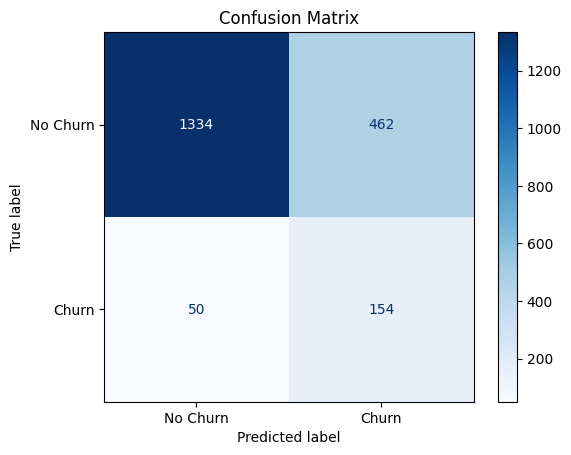

In [22]:
# Display confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Churn','Churn'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [23]:
# Values for true negative (tn), false positive (fp), false negative (fn), and true positive (tp)
tn, fp, fn, tp = cm.ravel()

print(f' fp: {fp} \n fn: {fn} \n tp: {tp} \n tn: {tn}')

 fp: 462 
 fn: 50 
 tp: 154 
 tn: 1334


In [24]:
# Calculations for accuracy, precision, recall
accuracy = round((tp + tn)/len(y_test), 4)
precision = round(tp/(tp + fp), 4)
recall = round(tp/(tp + fn), 4)

print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'-'*15)

Accuracy: 0.74
Precision: 0.25
Recall: 0.75
---------------


In [25]:
# Calculate f2 score
beta = 2
f2_score = (1 + beta**2) * (precision * recall) / (beta**2 * precision + recall)

print(f'The f2 score is {f2_score:.4f}')

The f2 score is 0.5377


**Profit/Loss analysis**     
The profit/loss analysis compares the relative performance of the models financially. For demonstration purposes, the following values are used:     
**L** = value of retaining a churner (lifetime value) is \$500      
**C** = cost of retention action is \$40     
True positives (**TP**) are correctly identified churners (retention action is spent but the value is saved).   
False positives (**FP**) stay but predicted to leave (retention action is spent but no value is saved).    
False negatives (**FN)** are predicted not to leave but leave (no retention action spent but value is lost).    
True negatives (**TN**) are correctly predicted not to leave (no retention action spent and no value is lost).

In [26]:
# Profit/loss analysis
L=500
C=40
profit_loss = tp*(L - C) - fp*C - fn*L

print(f'The profit or loss is ${profit_loss:,}')

The profit or loss is $27,360


**ROC Curve**    
The ROC Curve is plotted and the optimum threshold is obtained.

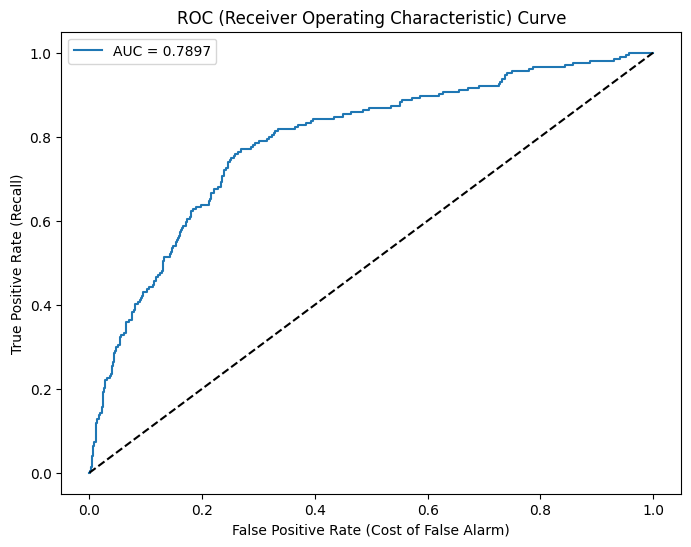

In [27]:
# Plot the ROC Curve
y_probs = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc = round(roc_auc_score(y_test, y_probs), 4)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_probs):.4f}')
plt.plot([0,1], [0,1], 'k--') # diagonal line representing random guessing
plt.title('ROC (Receiver Operating Characteristic) Curve')
plt.xlabel('False Positive Rate (Cost of False Alarm)')
plt.ylabel('True Positive Rate (Recall)')
plt.legend()
plt.show()

In [28]:
# Find the optimal threshold from the ROC Curve that maximizes Youden's J
optimal_idx = np.argmax(tpr-fpr)
optimal_threshold = thresholds[optimal_idx]

print(f'The optimal threshold is {optimal_threshold :.4f}')

The optimal threshold is 0.4873


**Threshold that maximizes profit**    
The threshold that maximizes profit is obtained from the precision-recall curve

In [29]:
# Calculate precision and recall for all thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
avg_precision = average_precision_score(y_test, y_probs)

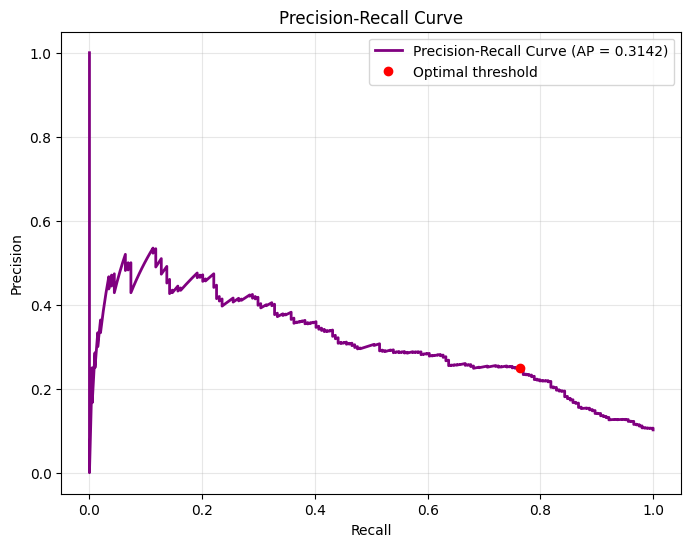

In [30]:
# Plot the precision-recall curve
plt.figure(figsize=(8,6))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AP = {avg_precision:.4f})', color='purple', lw=2)
# Mark the optimal threshold on the plot
idx = np.argmin(np.abs(thresholds-optimal_threshold))
plt.plot(recall[idx], precision[idx], 'ro', label='Optimal threshold')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(alpha=0.3)
plt.legend(loc='best')
plt.show()

In [31]:
# Evaluate precision and recall at different thresholds
thresholds = np.arange(0, 0.25, 0.01)
for threshold in thresholds:
    preds = (y_probs >= threshold).astype(int)
    print(f'Threshold={threshold:.2f} | Precision={precision_score(y_test, preds):.2f} | Recall={recall_score(y_test, preds):.2f}')

Threshold=0.00 | Precision=0.10 | Recall=1.00
Threshold=0.01 | Precision=0.10 | Recall=1.00
Threshold=0.02 | Precision=0.10 | Recall=1.00
Threshold=0.03 | Precision=0.10 | Recall=1.00
Threshold=0.04 | Precision=0.10 | Recall=1.00
Threshold=0.05 | Precision=0.10 | Recall=1.00
Threshold=0.06 | Precision=0.10 | Recall=1.00
Threshold=0.07 | Precision=0.10 | Recall=1.00
Threshold=0.08 | Precision=0.10 | Recall=1.00
Threshold=0.09 | Precision=0.10 | Recall=1.00
Threshold=0.10 | Precision=0.10 | Recall=1.00
Threshold=0.11 | Precision=0.10 | Recall=1.00
Threshold=0.12 | Precision=0.10 | Recall=1.00
Threshold=0.13 | Precision=0.10 | Recall=1.00
Threshold=0.14 | Precision=0.11 | Recall=1.00
Threshold=0.15 | Precision=0.11 | Recall=0.99
Threshold=0.16 | Precision=0.11 | Recall=0.98
Threshold=0.17 | Precision=0.11 | Recall=0.98
Threshold=0.18 | Precision=0.12 | Recall=0.97
Threshold=0.19 | Precision=0.12 | Recall=0.97
Threshold=0.20 | Precision=0.13 | Recall=0.95
Threshold=0.21 | Precision=0.13 | 

In [32]:
# Determine the threshold that maximizes profit
profits = []
for t in thresholds:
    y_pred = (y_probs >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    profit_loss = tp*(L - C) - fp*C - fn*L
    profits.append(profit_loss)

best_threshold = thresholds[np.argmax(profits)]

print(f'The threshold that maximizes profit is {best_threshold}')

The threshold that maximizes profit is 0.2


In [33]:
# Use the threshold that maximizes profit
y_pred = (y_probs >= best_threshold).astype(int)

In [34]:
# Generate classification report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.26      0.41      1796
           1       0.13      0.95      0.22       204

    accuracy                           0.33      2000
   macro avg       0.55      0.60      0.32      2000
weighted avg       0.89      0.33      0.39      2000



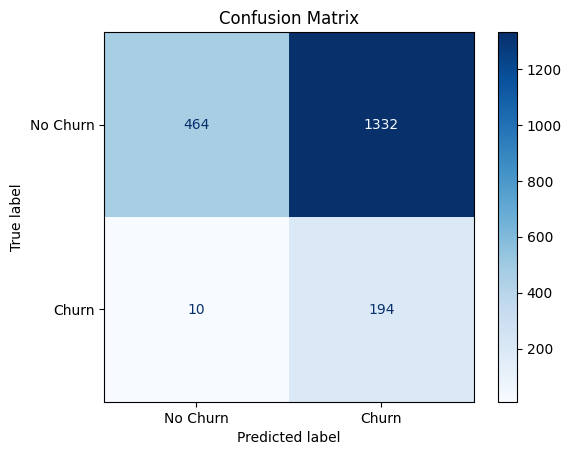

In [35]:
# Display confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Churn','Churn'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [36]:
# Values for true negative (tn), false positive (fp), false negative (fn), and true positive (tp)
tn, fp, fn, tp = cm.ravel()

print(f' fp: {fp} \n fn: {fn} \n tp: {tp} \n tn: {tn}')

 fp: 1332 
 fn: 10 
 tp: 194 
 tn: 464


In [37]:
# Calculations for accuracy, precision, recall
accuracy = round((tp + tn)/len(y_test), 4)
precision = round(tp/(tp + fp), 4)
recall = round(tp/(tp + fn), 4)

print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'-'*15)

Accuracy: 0.33
Precision: 0.13
Recall: 0.95
---------------


In [38]:
# Calculate f2 score
beta = 2
f2_score = round((1 + beta**2) * (precision * recall) / (beta**2 * precision + recall), 4)

print(f'The f2 score is {f2_score:.4f}')

The f2 score is 0.4141


In [39]:
# Profit/loss analysis
profit_loss = tp*(L - C) - fp*C - fn*L

print(f'The profit or loss is ${profit_loss:,}')

The profit or loss is $30,960


**Feature Selection**

In [40]:
# Verify number of features
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

print(f'The number of transformed features is {len(feature_names)}')

The number of transformed features is 147


In [41]:
# Determine the best number of features
results = []
feature_counts = [80, 100, 120, 147]
# Transform
X_train_trans = preprocessor.fit_transform(X_train)
X_test_trans = preprocessor.transform(X_test)

for k in feature_counts:
    # Selector
    selector = RFE(
        estimator=LogisticRegression(
            max_iter=1000,
            random_state=42
        ),
        n_features_to_select=k
    )
    # Feature selection
    X_train_selected = selector.fit_transform(
        X_train_trans,
        y_train
    )
    X_test_selected = selector.transform(
        X_test_trans
    )
    # Final model
    model = LogisticRegression(class_weight='balanced', random_state=42)
    model.fit(X_train_selected, y_train)
    # Predictions
    y_pred = model.predict(X_test_selected)
    y_proba = model.predict_proba(X_test_selected)[:, 1]
    # Metrics
    recall = recall_score(
        y_test,
        y_pred,
        average='macro'
    )
    f1 = f1_score(
        y_test,
        y_pred,
        average='macro'
    )
    accuracy = accuracy_score(
        y_test,
        y_pred
    )
    auc = roc_auc_score(y_test, y_proba)
    # Store results
    results.append({
        "num_features": k,
        "accuracy": accuracy,
        "recall": recall,
        "f1": f1,
        "auc": auc
    })
    # Selected features
    feature_names = preprocessor.get_feature_names_out()
    selected_features = feature_names[
      selector.get_support()
    ]

    print(f"\nTop {k} Features:")
    print(selected_features.tolist())

# Summary table
results_df = pd.DataFrame(results)

print("\nPerformance Summary:")
print(results_df)


Top 80 Features:
['nom__country_Bangladesh', 'nom__country_Germany', 'nom__country_India', 'nom__country_UK', 'nom__country_USA', 'nom__city_Delhi', 'nom__city_New York', 'nom__city_Sydney', 'nom__city_Toronto', 'nom__signup_channel_Referral', 'nom__signup_channel_Web', 'nom__features_used_Many', 'nom__features_used_Medium', 'nom__payment_method_Card', 'nom__payment_method_PayPal', 'nom__discount_applied_Yes', 'nom__complaint_type_Service', 'nom__tenure_group_(24, 36]', 'nom__tenure_group_(36, 52]', 'nom__tenure_group_(4, 24]', 'remainder__tenure_months', 'remainder__monthly_logins', 'remainder__last_login_days_ago', 'remainder__payment_failures', 'remainder__avg_resolution_time', 'remainder__csat_score', 'remainder__referral_count', 'remainder__tenure_fee_interaction', 'remainder__is_new_customer', 'remainder__activity_ratio', 'remainder__usage_trend', 'remainder__auto_payment', 'remainder__negative_customer', 'remainder__has_referrals', 'remainder__referral_tenure', 'remainder__loya

Choose 100 features (the performance difference is slight compared to the significant noise reduction).

In [42]:
# Define final selector
selector = RFE(
    estimator=LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    n_features_to_select=100
)

In [43]:
# Build pipeline
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('selector', selector),
    ('lgr', LogisticRegression(random_state=42))
])
pipe.fit(X_train, y_train)
pipe

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder=StandardScaler(),
                                   transformers=[('ord',
                                                  OrdinalEncoder(categories=[['Monthly',
                                                                              'Quarterly',
                                                                              'Yearly'],
                                                                             ['Unsatisfied',
                                                                              'Neutral',
                                                                              'Satisfied'],
                                                                             ['Individual',
                                                                              'SME',
                                                                              'Enterprise']]),
                                                  ['contract_type',
                                                   'survey_response',
                                                   'customer_segment']),
                                                 ('nom',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['gender', 'country', 'city',
                                                   'signup_channel',
                                                   'features_used',
                                                   'payment_method',
                                                   'discount_applied',
                                                   'price_increase_last_3m',
                                                   'complaint_type',
                                                   'tenure_group'])])),
                ('selector',
                 RFE(estimator=LogisticRegression(max_iter=1000,
                                                  random_state=42),
                     n_features_to_select=100)),
                ('lgr', LogisticRegression(random_state=42))])

In [44]:
# Accuracy of model on train and test data
pipe_acc_train = pipe.score(X_train, y_train)
pipe_acc_test = pipe.score(X_test, y_test)

print(f'The train accuracy of the model is {pipe_acc_train*100:.2f}%')
print(f'The test accuracy of the model is {pipe_acc_test*100:.2f}%')

The train accuracy of the model is 89.94%
The test accuracy of the model is 89.55%


In [45]:
# Define parameter grid
param_grid = {
    'lgr__penalty': ['l1','l2'],
    'lgr__solver': ['saga'],
    'lgr__C': np.logspace(-3,3,8),
    'lgr__max_iter': [500, 1000, 1500],
    'lgr__class_weight': ['balanced']
}

In [46]:
# Run HalvingRandomSearchCV to find the optimum mix of parameters
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
grid = HalvingRandomSearchCV(pipe, param_grid, cv=cv, scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)

print(f'Best parameters: {grid.best_params_}')
print(f'Best score: {grid.best_score_:.4f}')

Best parameters: {'lgr__solver': 'saga', 'lgr__penalty': 'l1', 'lgr__max_iter': 1500, 'lgr__class_weight': 'balanced', 'lgr__C': np.float64(1000.0)}
Best score: 0.1982


In [47]:
# Access the optimized xgb_pipe1 pipeline model
best_model = grid.best_estimator_
best_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder=StandardScaler(),
                                   transformers=[('ord',
                                                  OrdinalEncoder(categories=[['Monthly',
                                                                              'Quarterly',
                                                                              'Yearly'],
                                                                             ['Unsatisfied',
                                                                              'Neutral',
                                                                              'Satisfied'],
                                                                             ['Individual',
                                                                              'SME',
                                                                              'Enterprise']]),
                                                  ['contract_type',
                                                   'survey_response',
                                                   'customer_segment']),
                                                 ('nom',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['g...
                                                   'signup_channel',
                                                   'features_used',
                                                   'payment_method',
                                                   'discount_applied',
                                                   'price_increase_last_3m',
                                                   'complaint_type',
                                                   'tenure_group'])])),
                ('selector',
                 RFE(estimator=LogisticRegression(max_iter=1000,
                                                  random_state=42),
                     n_features_to_select=100)),
                ('lgr',
                 LogisticRegression(C=np.float64(1000.0),
                                    class_weight='balanced', max_iter=1500,
                                    penalty='l1', random_state=42,
                                    solver='saga'))])

In [48]:
# Accuracy of model on train and test data
best_model_acc_train = best_model.score(X_train, y_train)
best_model_acc_test = best_model.score(X_test, y_test)

print(f'The train accuracy of the model is {best_model_acc_train*100:.2f}%')
print(f'The test accuracy of the model is {best_model_acc_test*100:.2f}%')

The train accuracy of the model is 75.02%
The test accuracy of the model is 74.00%


In [49]:
# Generate classification report
y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.74      0.84      1796
           1       0.25      0.75      0.37       204

    accuracy                           0.74      2000
   macro avg       0.60      0.74      0.60      2000
weighted avg       0.89      0.74      0.79      2000



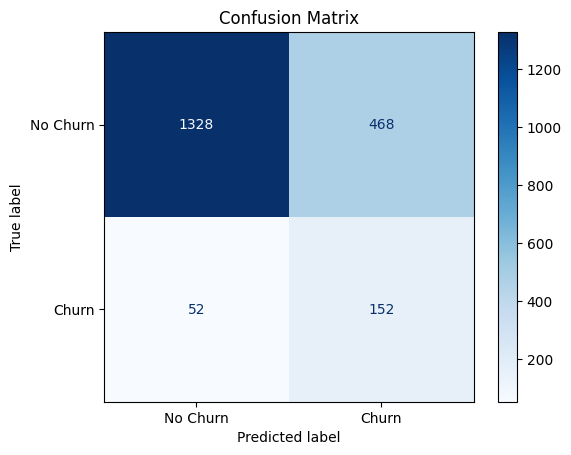

In [50]:
# Display confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Churn','Churn'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [51]:
# Values for true negative (tn), false positive (fp), false negative (fn), and true positive (tp)
tn, fp, fn, tp = cm.ravel()

print(f' fp: {fp} \n fn: {fn} \n tp: {tp} \n tn: {tn}')

 fp: 468 
 fn: 52 
 tp: 152 
 tn: 1328


In [52]:
# Calculations for accuracy, precision, recall
accuracy = round((tp + tn)/len(y_test), 4)
precision = round(tp/(tp + fp), 4)
recall = round(tp/(tp + fn), 4)

print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'-'*15)

Accuracy: 0.74
Precision: 0.25
Recall: 0.75
---------------


In [53]:
# Calculate f2 score
beta = 2
f2_score = round((1 + beta**2) * (precision * recall) / (beta**2 * precision + recall), 4)

print(f'The f2 score is {f2_score:.4f}')

The f2 score is 0.5293


In [54]:
# Profit/loss analysis
profit_loss = tp*(L - C) - fp*C - fn*L

print(f'The profit or loss is ${profit_loss:,}')

The profit or loss is $25,200


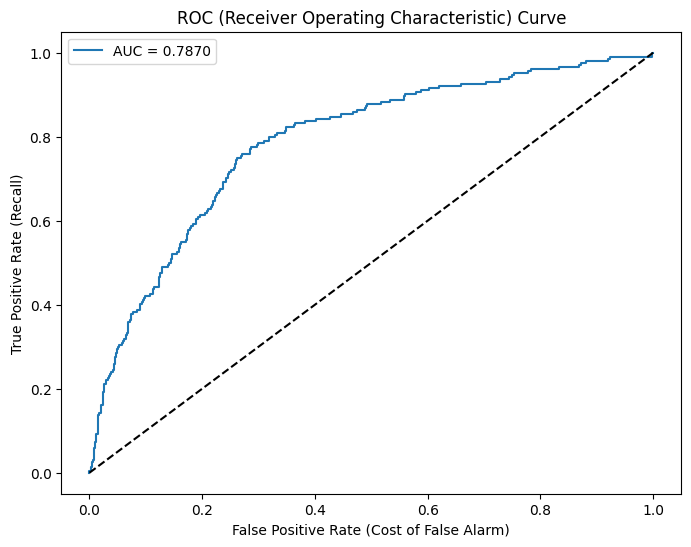

In [55]:
# Plot the ROC Curve
y_probs = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc = round(roc_auc_score(y_test, y_probs), 4)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_probs):.4f}')
plt.plot([0,1], [0,1], 'k--') # diagonal line representing random guessing
plt.title('ROC (Receiver Operating Characteristic) Curve')
plt.xlabel('False Positive Rate (Cost of False Alarm)')
plt.ylabel('True Positive Rate (Recall)')
plt.legend()
plt.show()

In [56]:
# Find the optimal threshold from the ROC Curve that maximizes Youden's J
optimal_idx = np.argmax(tpr-fpr)
optimal_threshold = thresholds[optimal_idx]

print(f'The optimal threshold is {optimal_threshold :.4f}')

The optimal threshold is 0.4714


In [57]:
# Calculate precision and recall for all thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
avg_precision = average_precision_score(y_test, y_probs)

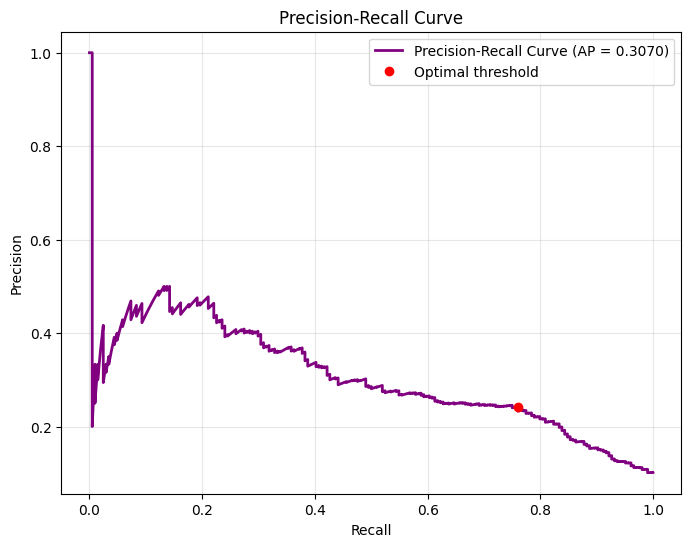

In [58]:
# Plot the precision-recall curve
plt.figure(figsize=(8,6))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AP = {avg_precision:.4f})', color='purple', lw=2)
# Mark the optimal threshold on the plot
idx = np.argmin(np.abs(thresholds-optimal_threshold))
plt.plot(recall[idx], precision[idx], 'ro', label='Optimal threshold')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(alpha=0.3)
plt.legend(loc='best')
plt.show()

In [59]:
# Evaluate precision and recall at different thresholds
thresholds = np.arange(0.20, 0.40, 0.01)
for threshold in thresholds:
    preds = (y_probs >= threshold).astype(int)
    print(f'Threshold={threshold:.2f} | Precision={precision_score(y_test, preds):.2f} | Recall={recall_score(y_test, preds):.2f}')

Threshold=0.20 | Precision=0.14 | Recall=0.92
Threshold=0.21 | Precision=0.15 | Recall=0.91
Threshold=0.22 | Precision=0.15 | Recall=0.90
Threshold=0.23 | Precision=0.16 | Recall=0.89
Threshold=0.24 | Precision=0.16 | Recall=0.88
Threshold=0.25 | Precision=0.17 | Recall=0.88
Threshold=0.26 | Precision=0.17 | Recall=0.86
Threshold=0.27 | Precision=0.17 | Recall=0.85
Threshold=0.28 | Precision=0.18 | Recall=0.85
Threshold=0.29 | Precision=0.19 | Recall=0.84
Threshold=0.30 | Precision=0.19 | Recall=0.84
Threshold=0.31 | Precision=0.20 | Recall=0.83
Threshold=0.32 | Precision=0.21 | Recall=0.83
Threshold=0.33 | Precision=0.21 | Recall=0.82
Threshold=0.34 | Precision=0.21 | Recall=0.81
Threshold=0.35 | Precision=0.22 | Recall=0.80
Threshold=0.36 | Precision=0.22 | Recall=0.80
Threshold=0.37 | Precision=0.22 | Recall=0.79
Threshold=0.38 | Precision=0.22 | Recall=0.79
Threshold=0.39 | Precision=0.23 | Recall=0.78


In [60]:
# Determine the threshold that maximizes profit
profits = []
for t in thresholds:
    y_pred = (y_probs >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    profit_loss = tp*(L - C) - fp*C - fn*L
    profits.append(profit_loss)

best_threshold = thresholds[np.argmax(profits)]

print(f'The threshold that maximizes profit is {best_threshold}')

The threshold that maximizes profit is 0.3200000000000001


In [61]:
# Use the threshold that maximizes profit
y_pred = (y_probs >= best_threshold).astype(int)

In [62]:
# Generate classification report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.63      0.77      1796
           1       0.21      0.83      0.33       204

    accuracy                           0.65      2000
   macro avg       0.59      0.73      0.55      2000
weighted avg       0.89      0.65      0.72      2000



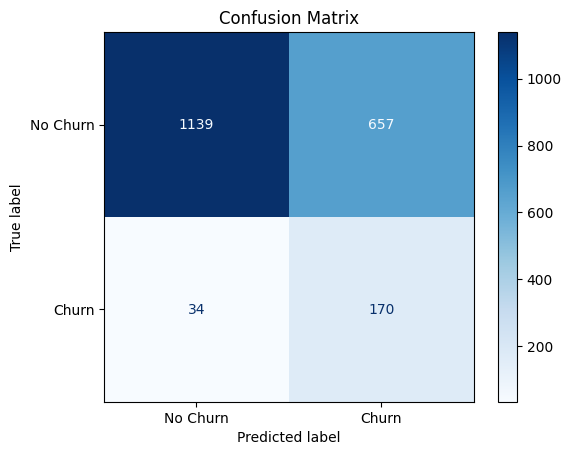

In [63]:
# Display confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Churn','Churn'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [64]:
# Values for true negative (tn), false positive (fp), false negative (fn), and true positive (tp)
tn, fp, fn, tp = cm.ravel()

print(f' fp: {fp} \n fn: {fn} \n tp: {tp} \n tn: {tn}')

 fp: 657 
 fn: 34 
 tp: 170 
 tn: 1139


In [65]:
# Calculations for accuracy, precision, recall
accuracy = round((tp + tn)/len(y_test), 4)
precision = round(tp/(tp + fp), 4)
recall = round(tp/(tp + fn), 4)

print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'-'*15)

Accuracy: 0.65
Precision: 0.21
Recall: 0.83
---------------


In [66]:
# Calculate f2 score
beta = 2
f2_score = round((1 + beta**2) * (precision * recall) / (beta**2 * precision + recall), 4)

print(f'The f2 score is {f2_score:.4f}')

The f2 score is 0.5174


In [67]:
# Profit/loss analysis
profit_loss = tp*(L - C) - fp*C - fn*L

print(f'The profit or loss is ${profit_loss:,}')

The profit or loss is $34,920


**Feature Importance**     


In [68]:
# Extract feature names
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

print(f'The feature names are: \n \n {feature_names} \n')
print(f'There are {len(feature_names)} feature names.')

The feature names are: 
 
 ['ord__contract_type' 'ord__survey_response' 'ord__customer_segment'
 'nom__gender_Male' 'nom__country_Bangladesh' 'nom__country_Canada'
 'nom__country_Germany' 'nom__country_India' 'nom__country_UK'
 'nom__country_USA' 'nom__city_Delhi' 'nom__city_Dhaka' 'nom__city_London'
 'nom__city_New York' 'nom__city_Sydney' 'nom__city_Toronto'
 'nom__signup_channel_Referral' 'nom__signup_channel_Web'
 'nom__features_used_Many' 'nom__features_used_Medium'
 'nom__payment_method_Card' 'nom__payment_method_PayPal'
 'nom__discount_applied_Yes' 'nom__price_increase_last_3m_Yes'
 'nom__complaint_type_Service' 'nom__complaint_type_Technical'
 'nom__tenure_group_(24, 36]' 'nom__tenure_group_(36, 52]'
 'nom__tenure_group_(4, 24]' 'nom__tenure_group_(52, 59]' 'remainder__age'
 'remainder__tenure_months' 'remainder__monthly_logins'
 'remainder__weekly_active_days' 'remainder__avg_session_time'
 'remainder__usage_growth_rate' 'remainder__last_login_days_ago'
 'remainder__monthly_fe

In [69]:
# Extract selected features
selector = best_model.named_steps["selector"]
mask = selector.get_support()
selected_features = feature_names[mask]
selected_features = [i.split('__')[-1] for i in selected_features]  # clean names

print(f'The selected features are: \n \n {selected_features} \n')
print(f'There are {len(selected_features)} selected features.')

The selected features are: 
 
 ['customer_segment', 'gender_Male', 'country_Bangladesh', 'country_Germany', 'country_India', 'country_UK', 'country_USA', 'city_Delhi', 'city_New York', 'city_Sydney', 'city_Toronto', 'signup_channel_Referral', 'signup_channel_Web', 'features_used_Many', 'features_used_Medium', 'payment_method_Card', 'payment_method_PayPal', 'discount_applied_Yes', 'complaint_type_Service', 'complaint_type_Technical', 'tenure_group_(24, 36]', 'tenure_group_(36, 52]', 'tenure_group_(4, 24]', 'tenure_group_(52, 59]', 'tenure_months', 'monthly_logins', 'weekly_active_days', 'last_login_days_ago', 'total_revenue', 'payment_failures', 'avg_resolution_time', 'csat_score', 'referral_count', 'tenure_fee_interaction', 'charge_increase', 'is_new_customer', 'activity_ratio', 'usage_trend', 'auto_payment', 'negative_customer', 'no_referrals', 'has_referrals', 'high_escalations', 'referral_tenure', 'loyal_monthly_customer', 'tickets_support', 'not_happy_customer', 'high_fee_customer'

In [70]:
# Extract coefficients
coefficients = best_model.named_steps['lgr'].coef_[0]

print(f'The coefficients are: \n \n {coefficients} \n')
print(f'There are {len(coefficients)} coefficients.')

The coefficients are: 
 
 [ 0.05464844 -0.10389297 -0.21614898  0.17281513 -0.02452018 -0.07482482
 -0.25376767  0.16575194  0.20104211  0.19332021  0.2226609   0.18184671
 -0.05393714  0.06841423 -0.08318723  0.10317425 -0.02513293 -0.1205714
 -0.07164955  0.02876276 -0.44772654 -0.19394851 -0.76220825  0.41965317
 -0.53542641 -0.11187481  0.08117729  0.18319833 -0.01268752  0.37328925
 -0.09386935  0.01408732 -0.30287618 -0.01268752  0.11227906 -0.04328916
 -0.14806646 -0.08326826 -0.09009099 -0.03952855 -0.05223765  0.05223765
  0.00737849  0.08676495  0.13191308 -0.1810405   0.90849193  0.08175768
  0.06528345  0.39590871  0.24391545  0.20111716  0.04620253 -0.24718658
 -0.06274828  0.02207294  0.04082476 -0.19760106  0.00872591  0.37400096
 -0.09108202 -0.03941356  0.20424044  0.10561848 -0.07523495  0.05230077
 -0.16975463 -0.48946448 -0.13626164  0.03927694 -0.04252456  0.06528345
 -0.12040474  0.02675166  0.07734278 -0.00373488  0.07402417 -0.03941356
  0.0299911  -0.04383206  

In [71]:
# Construct a dataframe of coefficients
coef_df = pd.DataFrame({'feature': selected_features, 'coefs': coefficients})
coef_df = coef_df.sort_values(by='coefs', ascending=False)

print(coef_df.head(10))

                  feature     coefs
46     not_happy_customer  0.908492
96     low_monthly_logins  0.534298
23  tenure_group_(52, 59]  0.419653
49       high_risk_flags2  0.395909
59      high_risk_flags16  0.374001
29       payment_failures  0.373289
50       high_risk_flags5  0.243915
88      high_risk_flags58  0.240376
10           city_Toronto  0.222661
62      high_risk_flags19  0.204240


In [72]:
# Extract the list of selected features and coefficients for plotting
feature1 = coef_df.iloc[:9,0]
feature2 = coef_df.iloc[-8:,0]
features = pd.concat([feature1, feature2])
features = pd.DataFrame(features)
features_list = features.values.tolist()
features_list = [item for sublist in features_list for item in sublist]

coef1 = coef_df.iloc[:9,1]
coef2 = coef_df.iloc[-8:,1]
coefs = pd.concat([coef1, coef2])
coefs = pd.DataFrame(coefs)
coefs_list = coefs.values.tolist()
coefs_list = [item for sublist in coefs_list for item in sublist]

In [73]:
# Prepare to plot the important features and coefficients

plot_data_lgr = {
    'feature': features_list,
    'coefs': coefs_list
}

plot_lgr_df = pd.DataFrame(plot_data_lgr)
plot_lgr_df = plot_lgr_df.sort_values(by='coefs', ascending=True)

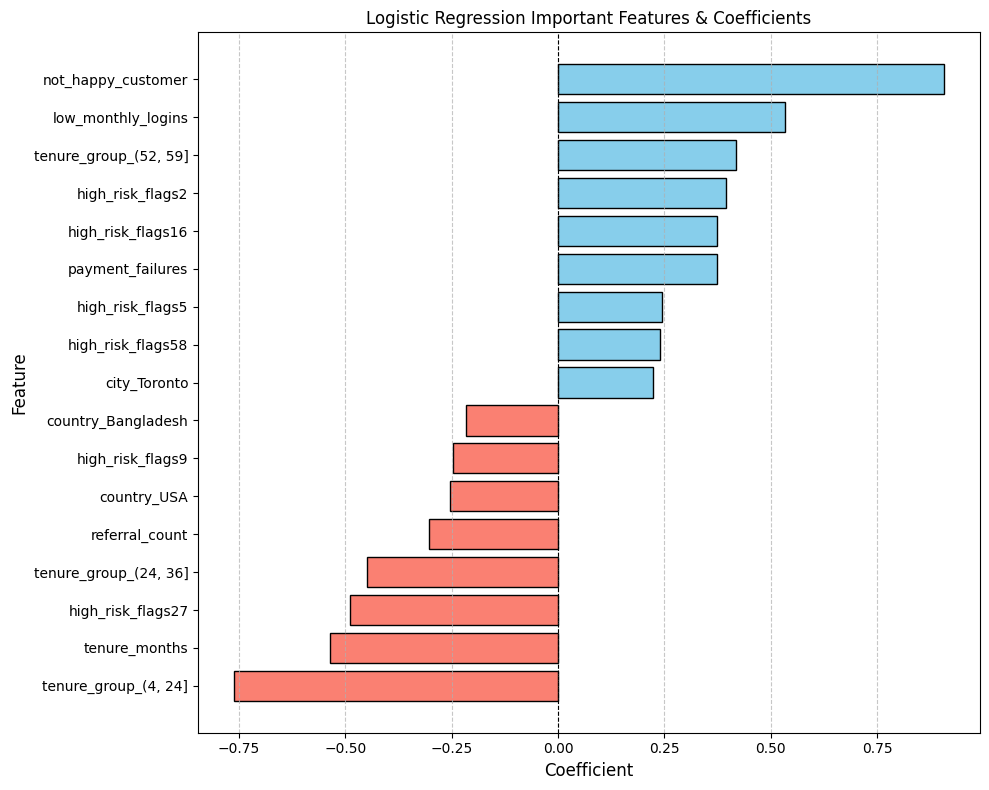

In [74]:
# Plot the feature and importance
plt.figure(figsize=(10, 8))
colors = ['salmon' if x < 0 else 'skyblue' for x in plot_lgr_df['coefs']]
plt.barh(plot_lgr_df['feature'], plot_lgr_df['coefs'], color=colors, edgecolor='black')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.title('Logistic Regression Important Features & Coefficients')
plt.xlabel('Coefficient', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Churn Odds**    
**payment failures** is the number one predictor for churn. A customer with failed payments is significantly more likely to leave. A unit increase in payment failures raises odds of churn by the **percent_change** assuming all other variables remain constant.         
As these values go up, the probability of churn increases.  

On the other hand, **csat score** is the number one retention factor. High customer satisfaction is the strongest signal that a customer will stay. A unit increase in customer satisfaction scores decreases odds of churn by the **percent_change** assuming all other variables remain constant.

**monthly logins** - high product engagement is a major indicator of a healthy customer who will continue to stay.    

**tenure months** is another anchor - the longer a customer stays, the less likely it is to leave.           

As these values go up, the probability of churn decreases.

In [75]:
# Calculate odds ratios and percentage change in odds
coef_df['odds_ratio'] = np.exp(coef_df['coefs'])
coef_df['percent_change'] = (coef_df['odds_ratio'] - 1) * 100

# Sort by coefficient
coef_df = coef_df.sort_values(by='coefs', ascending=False)
coef_df.head(44)

,feature,coefs,odds_ratio,percent_change
46,not_happy_customer,0.908492,2.480579,148.057882
96,low_monthly_logins,0.534298,1.706249,70.624946
23,"tenure_group_(52, 59]",0.419653,1.521434,52.143378
49,high_risk_flags2,0.395909,1.485734,48.573368
59,high_risk_flags16,0.374001,1.453539,45.353855
29,payment_failures,0.373289,1.452504,45.250442
50,high_risk_flags5,0.243915,1.276236,27.623642
88,high_risk_flags58,0.240376,1.271728,27.172775
10,city_Toronto,0.222661,1.249397,24.939684
62,high_risk_flags19,0.204240,1.226593,22.659304


In [76]:
# Sort by coefs absolute values
coef_df['coefs'] = coef_df['coefs'].apply(abs)
#coef_df['abs_coef'] = coef_df['coefs'].abs()
coef_df = coef_df.sort_values(by = 'coefs', ascending = False)

coef_df.head(44)

,feature,coefs,odds_ratio,percent_change
46,not_happy_customer,0.908492,2.480579,148.057882
22,"tenure_group_(4, 24]",0.762208,0.466635,-53.336516
24,tenure_months,0.535426,0.585420,-41.458039
96,low_monthly_logins,0.534298,1.706249,70.624946
67,high_risk_flags27,0.489464,0.612955,-38.704545
20,"tenure_group_(24, 36]",0.447727,0.639079,-36.092058
23,"tenure_group_(52, 59]",0.419653,1.521434,52.143378
49,high_risk_flags2,0.395909,1.485734,48.573368
59,high_risk_flags16,0.374001,1.453539,45.353855
29,payment_failures,0.373289,1.452504,45.250442


In [77]:
# Reset index and get the first two columns
coef_df = coef_df.reset_index(drop=True)
coef_df.index = coef_df.index + 1
coef_df.index.name = "Rank"
coef_df = coef_df.iloc[:, :2]   # Slice dataframe

coef_df.head(10)

,feature,coefs
Rank,,
1,not_happy_customer,0.908492
2,"tenure_group_(4, 24]",0.762208
3,tenure_months,0.535426
4,low_monthly_logins,0.534298
5,high_risk_flags27,0.489464
6,"tenure_group_(24, 36]",0.447727
7,"tenure_group_(52, 59]",0.419653
8,high_risk_flags2,0.395909
9,high_risk_flags16,0.374001


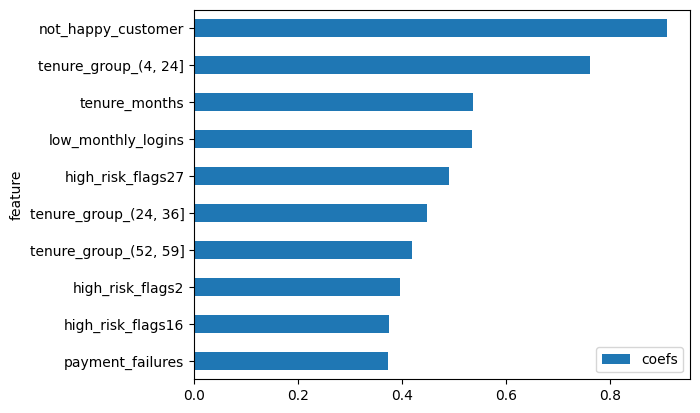

In [78]:
# Visualize
coef_df.head(10).plot(
    x="feature",
    y="coefs",
    kind="barh"
)
plt.gca().invert_yaxis()
plt.show()

**SHAP Analysis**     

Unhappy customers are much more likely to churn.
Very strong and expected business signal.

Newer customers are much more likely to churn.
Long-tenure customers are more loyal.

Tenure group (4, 24) is less likely to churn.

Low monthly logins and payment failures
are more likely to churn.

Those who refer are less likely to churn.

In [79]:
# Transform data
X_train_trans = preprocessor.fit_transform(
    X_train
)
X_test_trans = preprocessor.transform(
    X_test
)

In [80]:
# Select features by selector
X_train_selected = selector.fit_transform(
    X_train_trans,
    y_train
)

X_test_selected = selector.transform(
    X_test_trans
)

In [81]:
# Verify shapes

print(X_train_trans.shape)
print(X_train_selected.shape)

(8000, 147)
(8000, 100)


In [82]:
# Create selected features
feature_names = preprocessor.get_feature_names_out()

selected_features = feature_names[
    selector.get_support()
]
selected_features = [i.split('__')[-1] for i in selected_features]  # clean names

In [83]:
# Create dataframe
X_train_selected_df = pd.DataFrame(
    X_train_selected,
    columns=selected_features,
    index=X_train.index
)

In [84]:
# Initialize the TreeExplainer
explainer = shap.LinearExplainer(
    best_model.named_steps['lgr'],
    X_train_selected_df
)

In [85]:
# Pass the dataframe
shap_values = explainer.shap_values(X_train_selected_df)

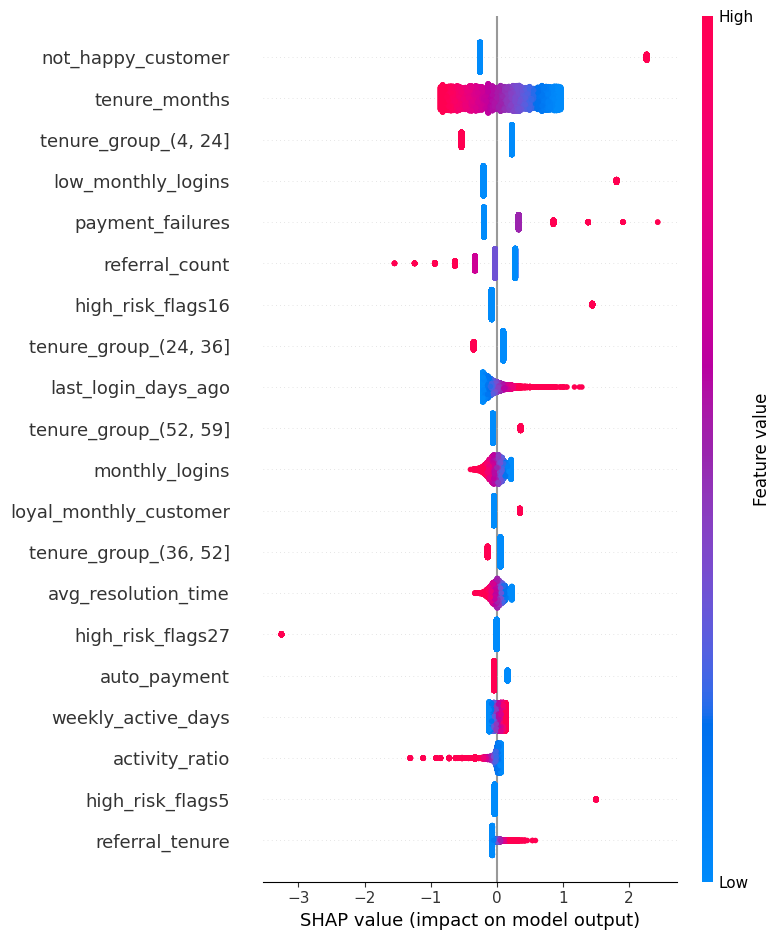

In [86]:
# Render the beeswarm plot
shap.summary_plot(shap_values, X_train_selected_df)

In [87]:
# Verify SHAP importance
shap_importance = pd.DataFrame({
    "feature": X_train_selected_df.columns,
    "importance": np.abs(shap_values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    by="importance",
    ascending=False
)

print(shap_importance.head(30))

                    feature  importance
46       not_happy_customer    0.561589
24            tenure_months    0.464415
22     tenure_group_(4, 24]    0.330036
96       low_monthly_logins    0.324125
29         payment_failures    0.305388
32           referral_count    0.229997
59        high_risk_flags16    0.164534
20    tenure_group_(24, 36]    0.149805
27      last_login_days_ago    0.146076
23    tenure_group_(52, 59]    0.096445
25           monthly_logins    0.090236
44   loyal_monthly_customer    0.082912
21    tenure_group_(36, 52]    0.078106
30      avg_resolution_time    0.075843
67        high_risk_flags27    0.075308
38             auto_payment    0.073063
26       weekly_active_days    0.071054
36           activity_ratio    0.069571
50         high_risk_flags5    0.068913
43          referral_tenure    0.066904
99        low_total_revenue    0.066481
2        country_Bangladesh    0.064322
49         high_risk_flags2    0.062579
6               country_USA    0.062158


**Model Summary**     
A dataframe is plotted to summarize the AUC, accuracy, precision, recall, F2 score and profit/loss.     

The ultimate choice of the predictive model would need to consider the actual relative cost of missing a churner (false negatives - predicted not to churn but churned) and false alarms (false positives - predicted to churn but stayed) in order to determine the optimum mix of precision and recall.  

In [88]:
# Build dataframe
lgr_model_df = pd.DataFrame({
    'Model': ['Logistic Regression'],
    'AUC': [auc],
    'Accuracy': [accuracy],
    'Precision': [precision],
    'Recall': [recall],
    'F2_Score': [f2_score],
    'Profit_Loss': [profit_loss],
})
lgr_model_df

,Model,AUC,Accuracy,Precision,Recall,F2_Score,Profit_Loss
0,Logistic Regression,0.787,0.6545,0.2056,0.8333,0.5174,34920


In [89]:
# Output model performance
lgr_model_df.to_csv("lgr_metrics.csv", index=False)

In [90]:
# Output the features importance
coef_df.to_csv("lgr_features.csv", index=False)

In [91]:
# Output the SHAP importance
shap_importance.to_csv("lgr_shap.csv", index=False)

**Sample Predictions**

In [92]:
# Obtain sample_1 from X_test
sample_1 = X_test.loc[[6563]]
proba_1 = best_model.predict_proba(sample_1)

print(f'The [[0, 1]] probabilities are {proba_1}')

The [[0, 1]] probabilities are [[0.77241857 0.22758143]]


In [93]:
# Verify actual churn

print("Actual churn:", y_test.loc[6563])

Actual churn: 1


In [94]:
# Predict a false negative
pred_1 = int(proba_1[:,1] >= best_threshold)

print("Predicted churn:", pred_1)

Predicted churn: 0


In [95]:
# Obtain sample_2 from X_test
sample_2 = X_test.loc[[4503]]
proba_2 = best_model.predict_proba(sample_2)

print(proba_2)

[[0.85084774 0.14915226]]


In [96]:
# Verify actual churn

print("Actual churn:", y_test.loc[4503])

Actual churn: 0


In [97]:
# Predict a true negative
pred_2 = int(proba_2[:,1] >= best_threshold)

print("Predicted churn:", pred_2)

Predicted churn: 0


In [98]:
# Obtain sample_3 from X_test
sample_3 = X_test.loc[[5978]]
proba_3 = best_model.predict_proba(sample_3)

print(proba_3)

[[0.74556989 0.25443011]]


In [99]:
# Verify actual churn

print("Actual churn:", y_test.loc[5978])

Actual churn: 1


In [100]:
# Predict a false negative
pred_3 = int(proba_3[:,1] >= best_threshold)

print("Predicted churn:", pred_3)

Predicted churn: 0
